Imports and Configuration

In [2]:
import os 
import json 
import time
import numpy as np
import pandas as pd
import requests
import streamlit as st
from collections import Counter, defaultdict
from getpass import getpass

import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline

os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


Streamlit Configuration

In [3]:
st.set_page_config(page_title="Wesnoth PR Clustering", layout="wide")
st.title("Patch Patterns: Clustering Similar Pull Requests")

2025-11-03 10:23:34.844 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:34.847 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:35.497 
  command:

    streamlit run C:\Users\kaosa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-11-03 10:23:35.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:35.500 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

Read GitHub token from Streamlit Secrets

In [4]:

GITHUB_TOKEN = st.secrets.get("GITHUB_TOKEN", "")
if not GITHUB_TOKEN:
    st.info("ℹ️ Add a GitHub token in Streamlit → Settings → Secrets as `GITHUB_TOKEN`.")


GitHub API helpers (cached)

In [5]:
@st.cache_data(show_spinner=False)
def gh_get(url: str, token: str, params: dict | None = None, accept: str | None = None):
    headers = {"Authorization": f"Bearer {token}"} if token else {}
    if accept: headers["Accept"] = accept
    r = requests.get(url, headers=headers, params=params, timeout=60)
    if r.status_code == 403 and "rate limit" in r.text.lower():
        reset = int(r.headers.get("X-RateLimit-Reset", time.time()+60))
        sleep_s = max(1, reset - int(time.time()) + 1)
        time.sleep(sleep_s)
        r = requests.get(url, headers=headers, params=params, timeout=60)
    r.raise_for_status()
    return r.json()


2025-11-03 10:23:36.056 No runtime found, using MemoryCacheStorageManager


In [6]:
@st.cache_data(show_spinner=True)
def fetch_merged_prs(owner: str, repo: str, target: int, token: str):
    GITHUB_API = "https://api.github.com"
    prs, page, per_page = [], 1, 100
    while len(prs) < target:
        url = f"{GITHUB_API}/repos/{owner}/{repo}/pulls"
        params = {"state": "closed", "per_page": per_page, "page": page, "sort": "updated", "direction": "desc"}
        batch = gh_get(url, token, params=params)
        if not batch: break
        merged = [pr for pr in batch if pr.get("merged_at")]
        prs.extend(merged)
        page += 1
        if len(batch) < per_page: break
    return prs[:target]



2025-11-03 10:23:36.084 No runtime found, using MemoryCacheStorageManager


Text building for embeddings

In [7]:
# --- Text block builder --- block 6
def build_text_block(rec: dict) -> str:
    title = rec.get("title") or ""
    body = rec.get("body") or ""
    commits = "\n".join(rec.get("commits_messages") or [])
    files = rec.get("files") or []
    changed_paths = " ".join([f.get("filename","") for f in files])
    return f"TITLE: {title}\nBODY: {body}\nCOMMITS:\n{commits}\nFILES: {changed_paths}".strip()


In [8]:
@st.cache_data(show_spinner=True)
def fetch_pr_details(owner: str, repo: str, numbers: list[int], token: str):
    GITHUB_API = "https://api.github.com"
    out = []
    for n in numbers:
        files = gh_get(f"{GITHUB_API}/repos/{owner}/{repo}/pulls/{n}/files", token)
        commits = gh_get(f"{GITHUB_API}/repos/{owner}/{repo}/pulls/{n}/commits", token)
        pr = gh_get(f"{GITHUB_API}/repos/{owner}/{repo}/pulls/{n}", token)
        file_entries = [{
            "filename": f.get("filename"),
            "status": f.get("status"),
            "additions": f.get("additions"),
            "deletions": f.get("deletions"),
            "changes":  f.get("changes"),
            "patch":    f.get("patch"),
        } for f in files]
        commit_msgs = [c.get("commit", {}).get("message","") for c in commits]
        labels = [lab.get("name") for lab in pr.get("labels", [])]
        out.append({
            "number": pr.get("number"),
            "title": pr.get("title"),
            "user": pr.get("user", {}).get("login"),
            "state": pr.get("state"),
            "merged_at": pr.get("merged_at"),
            "created_at": pr.get("created_at"),
            "updated_at": pr.get("updated_at"),
            "labels": labels,
            "body": pr.get("body"),
            "files": file_entries,
            "commits_messages": commit_msgs,
            "html_url": pr.get("html_url"),
        })
    return out


2025-11-03 10:23:36.137 No runtime found, using MemoryCacheStorageManager


Embedding model loading and encoding (cached)

In [9]:
# --- Embedding (cached) --- block 8
@st.cache_resource(show_spinner=True)
def load_embed_model(model_name: str):
    return SentenceTransformer(model_name)

@st.cache_data(show_spinner=True)
def embed_records(data: list[dict], model_name: str):
    texts = [build_text_block(r) for r in data]
    model = load_embed_model(model_name)
    emb = model.encode(texts, show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True)
    index_rows = [{
        "number": r.get("number"),
        "title": r.get("title"),
        "labels": ",".join(r.get("labels") or []),
        "url": r.get("html_url"),
    } for r in data]
    return emb, pd.DataFrame(index_rows), texts


2025-11-03 10:23:36.164 No runtime found, using MemoryCacheStorageManager


Clustering via threshold graph → connected components

In [10]:
# --- Clustering ---
def cluster_by_threshold(emb: np.ndarray, threshold: float):
    sim = cosine_similarity(emb)
    np.fill_diagonal(sim, 1.0)
    n = sim.shape[0]

    # Union-Find for connected components (faster than building NetworkX graph on large n)
    parent = list(range(n))
    rank = [0]*n
    def find(x):
        if parent[x]!=x: parent[x]=find(parent[x])
        return parent[x]
    def union(x,y):
        rx,ry = find(x),find(y)
        if rx==ry: return
        if rank[rx]<rank[ry]: parent[rx]=ry
        elif rank[rx]>rank[ry]: parent[ry]=rx
        else: parent[ry]=rx; rank[rx]+=1

    for i in range(n):
        row = sim[i, i+1:]
        js = np.where(row >= threshold)[0] + (i+1)
        for j in js: union(i,j)

    root_to_id, cid = {}, 0
    cluster_ids = np.zeros(n, dtype=int) - 1
    for i in range(n):
        r = find(i)
        if r not in root_to_id:
            root_to_id[r] = cid
            cid += 1
        cluster_ids[i] = root_to_id[r]
    return cluster_ids


Small utilities for preview and analysis

In [11]:
def top_title_tokens(df_with_titles: pd.DataFrame, max_tokens=8):
    import re
    rows = []
    grp = df_with_titles.groupby("cluster_id")
    for cid, g in grp:
        toks = []
        for t in g["title"].fillna(""):
            toks += [w for w in re.findall(r"[A-Za-z][A-Za-z0-9_+-]{2,}", t.lower())
                     if w not in {"the","and","for","with","into","from","this","that","fix","pr"}]
        common = " ".join([w for w,_ in Counter(toks).most_common(max_tokens)])
        rows.append({"cluster_id": cid, "n_items": len(g), "top_title_tokens": common})
    return pd.DataFrame(rows).sort_values("n_items", ascending=False)


In [12]:
def explode_labels(s: str) -> list[str]:
    if not isinstance(s, str) or not s.strip(): return []
    return [x.strip() for x in s.split(",") if x.strip()]

In [13]:
def path_counts_by_cluster(df_clusters: pd.DataFrame, num_to_record: dict[int, dict]):
    counts = defaultdict(Counter)
    for r in df_clusters.itertuples():
        rec = num_to_record.get(int(r.number))
        if not rec: continue
        for f in (rec.get("files") or []):
            fn = (f.get("filename") or "").strip()
            if fn:
                top = fn.split("/")[0] if "/" in fn else fn
                counts[r.cluster_id][top] += 1
    rows = []
    for cid, cnt in counts.items():
        for p, n in cnt.most_common(8):
            rows.append({"cluster_id": cid, "path": p, "count": n})
    return pd.DataFrame(rows)

Sidebar controls (owner/repo/target/model/threshold + buttons)

In [14]:
# --- Sidebar controls --- block 13
st.sidebar.header("Settings")
owner = st.sidebar.text_input("GitHub Owner", value="wesnoth")
repo = st.sidebar.text_input("GitHub Repo", value="wesnoth")
target = st.sidebar.slider("Merged PRs to fetch", min_value=100, max_value=600, value=400, step=50)
model_name = st.sidebar.text_input("Embedding model", value="sentence-transformers/all-MiniLM-L6-v2")
threshold = st.sidebar.slider("Clustering threshold", min_value=0.70, max_value=0.98, value=0.92, step=0.01)

fetch_btn = st.sidebar.button("1) Fetch PRs")
embed_btn = st.sidebar.button("2) Embed")
cluster_btn = st.sidebar.button("3) Cluster & Analyze")


2025-11-03 10:23:36.290 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.307 Session state does not function when running a script without `streamlit run`
2025-11-03 10:23

Session state

In [ ]:
# --- Session state store --- Block 14
if "raw_rows" not in st.session_state: st.session_state.raw_rows = None
if "index_df" not in st.session_state: st.session_state.index_df = None
if "emb" not in st.session_state: st.session_state.emb = None
if "cluster_df" not in st.session_state: st.session_state.cluster_df = None
if "text_blocks" not in st.session_state: st.session_state.text_blocks = None


2025-11-03 10:23:36.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.416 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.418 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.423 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.425 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.428 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Button actions (fetch → embed → cluster & analyze)

In [ ]:
if fetch_btn: ####block 15
    if not GITHUB_TOKEN:
        st.error("Please add `GITHUB_TOKEN` in your Streamlit app secrets.")
    else:
        st.info("Fetching merged PRs…")
        merged = fetch_merged_prs(owner, repo, target, GITHUB_TOKEN)
        numbers = [m["number"] for m in merged]
        rows = fetch_pr_details(owner, repo, numbers, GITHUB_TOKEN)
        st.session_state.raw_rows = rows
        st.success(f"Fetched {len(rows)} PRs.")
        st.dataframe(pd.DataFrame([{
            "number": r["number"], "title": r["title"], "labels": ", ".join(r.get("labels") or []), "url": r["html_url"]
        } for r in rows]).head(20))

In [17]:
if embed_btn:
    if not st.session_state.raw_rows:
        st.warning("Fetch PRs first.")
    else:
        st.info("Embedding PRs…")
        emb, index_df, texts = embed_records(st.session_state.raw_rows, model_name)
        st.session_state.emb = emb
        st.session_state.index_df = index_df
        st.session_state.text_blocks = texts
        st.success(f"Embeddings ready. Shape: {emb.shape}")
        st.dataframe(index_df.head(10))



In [18]:
if cluster_btn:
    if st.session_state.emb is None or st.session_state.index_df is None:
        st.warning("Run embedding first.")
    else:
        st.info("Clustering by threshold…")
        cids = cluster_by_threshold(st.session_state.emb, threshold)
        out = st.session_state.index_df.copy()
        out["cluster_id"] = cids
        st.session_state.cluster_df = out
        st.success("Clustering complete.")

        # Largest clusters
        st.subheader("Largest clusters")
        sizes = out.groupby("cluster_id")["number"].count().sort_values(ascending=False)
        st.write(sizes.head(20))

        # Preview keywords
        st.subheader("Cluster preview (top title tokens)")
        st.dataframe(top_title_tokens(out))

        # Labels per cluster
        st.subheader("Label heatmap rows (top labels per cluster)")
        label_rows = []
        grp = out.groupby("cluster_id")
        for cid, g in grp:
            cnt = Counter()
            for labs in g["labels"].fillna(""):
                cnt.update(explode_labels(labs))
            for lab, n in cnt.most_common(6):
                label_rows.append({"cluster_id": cid, "label": lab, "count": n})
        label_df = pd.DataFrame(label_rows)
        st.dataframe(label_df.head(40))

        # Path stats per cluster (uses original JSON)
        st.subheader("Path stats (top-level directories per cluster)")
        num_to_record = {r["number"]: r for r in st.session_state.raw_rows}
        path_df = path_counts_by_cluster(out, num_to_record)
        st.dataframe(path_df.head(40))


Similarity search

In [ ]:
# --- Similarity search --- Block 18
st.header("Similarity Search")
query = st.text_area("Paste a new issue/PR description", height=180,
                     placeholder="e.g., Fix AI pathfinding bug in campaign X …")
topk = st.slider("Top K", 5, 30, 10)

if st.button("Search similar PRs"):
    if st.session_state.emb is None or st.session_state.index_df is None:
        st.warning("Please embed (step 2) first.")
    else:
        model = load_embed_model(model_name)
        qv = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        sims = cosine_similarity(qv, st.session_state.emb)[0]
        order = np.argsort(-sims)[:topk]
        res = st.session_state.index_df.iloc[order].copy()
        res.insert(1, "similarity", sims[order])
        st.dataframe(res)
        for r in res.itertuples():
            st.markdown(f"**PR #{int(r.number)}** — [{r.title}]({r.url})  \nSimilarity: `{r.similarity:.3f}`  \nLabels: `{r.labels}`")


2025-11-03 10:23:36.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.573 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.579 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.585 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 10:23:36.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Fetching and Preparing Pull Request Data from GitHub

In [53]:
#block 19

OWNER, REPO, TARGET = "wesnoth", "wesnoth", 400
TOKEN = getpass("GitHub token: ")
API = "https://api.github.com"

def gh(url, params=None):
    h = {"Authorization": f"Bearer {TOKEN}"} if TOKEN else {}
    r = requests.get(url, headers=h, params=params, timeout=60)
    if r.status_code==403 and "rate limit" in r.text.lower():
        reset = int(r.headers.get("X-RateLimit-Reset", time.time()+60))
        time.sleep(max(1, reset-int(time.time())+1))
        r = requests.get(url, headers=h, params=params, timeout=60)
    r.raise_for_status()
    return r.json()

def fetch_merged_prs(owner, repo, target):
    out, page = [], 1
    while len(out)<target:
        batch = gh(f"{API}/repos/{owner}/{repo}/pulls",
                   {"state":"closed","per_page":100,"page":page,"sort":"updated","direction":"desc"})
        if not batch: break
        out += [pr for pr in batch if pr.get("merged_at")]
        page += 1
        if len(batch)<100: break
    return out[:target]

def details(owner, repo, num):
    files = gh(f"{API}/repos/{owner}/{repo}/pulls/{num}/files")
    commits = gh(f"{API}/repos/{owner}/{repo}/pulls/{num}/commits")
    pr = gh(f"{API}/repos/{owner}/{repo}/pulls/{num}")
    return {
        "number": pr["number"],
        "title": pr["title"],
        "labels": [x["name"] for x in pr.get("labels",[])],
        "body": pr.get("body"),
        "files": [{"filename": f.get("filename")} for f in files],
        "commits_messages": [c["commit"]["message"] for c in commits],
        "url": pr["html_url"]
    }



In [ ]:
#Block 20
merged = fetch_merged_prs(OWNER, REPO, TARGET)
rows = [details(OWNER, REPO, pr["number"]) for pr in merged]
os.makedirs("data", exist_ok=True)
json.dump(rows, open("data/wesnoth_pr_data.json","w"), indent=2)
idx = pd.DataFrame([{"number":r["number"],"title":r["title"],
                     "labels":",".join(r["labels"]), "url":r["url"]} for r in rows])
idx.to_csv("data/wesnoth_index.csv", index=False)
idx.head()

,number,title,labels,url
0,10651,Make help_manager a proper singleton,"UI,Editor,Help",https://github.com/wesnoth/wesnoth/pull/10651
1,10644,Registry for Abilities,"Units,Schema",https://github.com/wesnoth/wesnoth/pull/10644
2,10632,"Adjust L2/L3 Merfolk hp, damage, xp, and cost",Units,https://github.com/wesnoth/wesnoth/pull/10632
3,10617,TSG: assorted tutorial improvements,"Graphics,Units,Achievements,Campaign TSG",https://github.com/wesnoth/wesnoth/pull/10617
4,10650,WoF changelog entries for 1.19.16,,https://github.com/wesnoth/wesnoth/pull/10650


In [22]:

def block(r):
    files = " ".join([f.get("filename","") for f in r.get("files",[])])
    cmts = "\n".join(r.get("commits_messages",[]))
    return f"TITLE: {r.get('title','')}\nBODY: {r.get('body','')}\nCOMMITS:\n{cmts}\nFILES: {files}"

data = json.load(open("data/wesnoth_pr_data.json"))
texts = [block(r) for r in data]
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
emb = model.encode(texts, convert_to_numpy=True, normalize_embeddings=True)



In [23]:
# Save embeddings so we can reuse them later
np.save("data/wesnoth_embeddings.npy", emb)
print("Embeddings saved to data/wesnoth_embeddings.npy")

Embeddings saved to data/wesnoth_embeddings.npy


Threshold Clustering

In [ ]:
#block 23
def cluster(emb, thr=0.92):
    sim = cosine_similarity(emb); np.fill_diagonal(sim,1.0)
    n = sim.shape[0]
    parent = list(range(n)); rank=[0]*n
    def find(x):
        if parent[x]!=x: parent[x]=find(parent[x]); return parent[x]
        return x
    def union(a,b):
        ra,rb = find(a),find(b)
        if ra==rb: return
        if rank[ra]<rank[rb]: parent[ra]=rb
        elif rank[ra]>rank[rb]: parent[rb]=ra
        else: parent[rb]=ra; rank[ra]+=1
    for i in range(n):
        js = np.where(sim[i, i+1:]>=thr)[0]+(i+1)
        for j in js: union(i,j)
    roots = {}
    cid = np.full(n, -1)
    next_id=0
    for i in range(n):
        r = find(i)
        if r not in roots: roots[r]=next_id; next_id+=1
        cid[i]=roots[r]
    return cid

cids = cluster(emb, 0.92)
df = pd.read_csv("data/wesnoth_index.csv")
df["cluster_id"] = cids


In [25]:
os.makedirs("artifacts", exist_ok=True)
df.to_csv("artifacts/cluster_results_092.csv", index=False)
print("✅ Saved 0.92 threshold clustering results to artifacts/cluster_results_092.csv")

✅ Saved 0.92 threshold clustering results to artifacts/cluster_results_092.csv


Plot cluster sizes

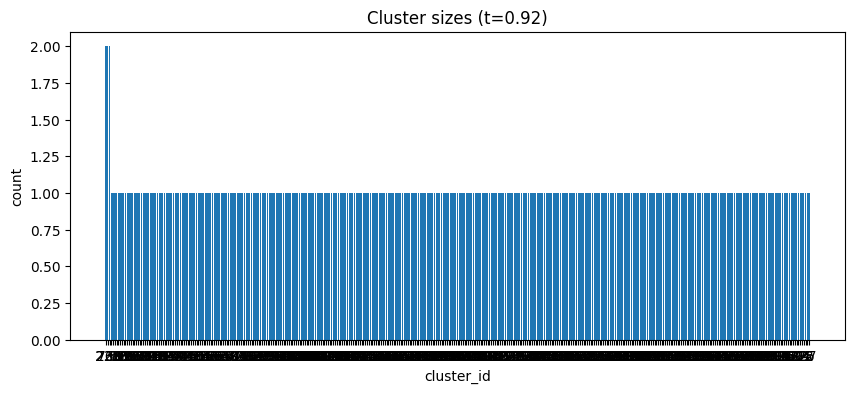

cluster_id
76     2
225    2
230    2
5      1
6      1
7      1
8      1
9      1
10     1
11     1
12     1
365    1
28     1
381    1
1      1
Name: number, dtype: int64

In [26]:
sizes = df.groupby("cluster_id")["number"].count().sort_values(ascending=False)
plt.figure(figsize=(10,4))
plt.bar(sizes.index.astype(str), sizes.values)
plt.title("Cluster sizes (t=0.92)"); plt.xlabel("cluster_id"); plt.ylabel("count")
plt.show()

sizes.head(15)

In [27]:
sizes.sort_values(ascending=False).head(10)


cluster_id
225    2
230    2
76     2
7      1
8      1
9      1
10     1
11     1
12     1
365    1
Name: number, dtype: int64

In [28]:
df[df["cluster_id"] == 68][["number", "title", "labels", "url"]]


,number,title,labels,url
68,10524,Changing the weapon special [defense] into an ...,"Unit Tests,Units,Schema,Campaign UtBS,Campaign...",https://github.com/wesnoth/wesnoth/pull/10524


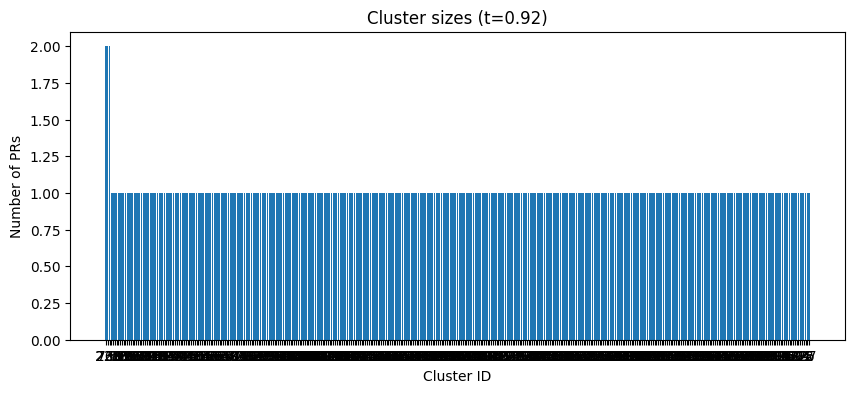

In [29]:

plt.figure(figsize=(10,4))
plt.bar(sizes.index.astype(str), sizes.values)
plt.title("Cluster sizes (t=0.92)")
plt.xlabel("Cluster ID")
plt.ylabel("Number of PRs")
plt.show()


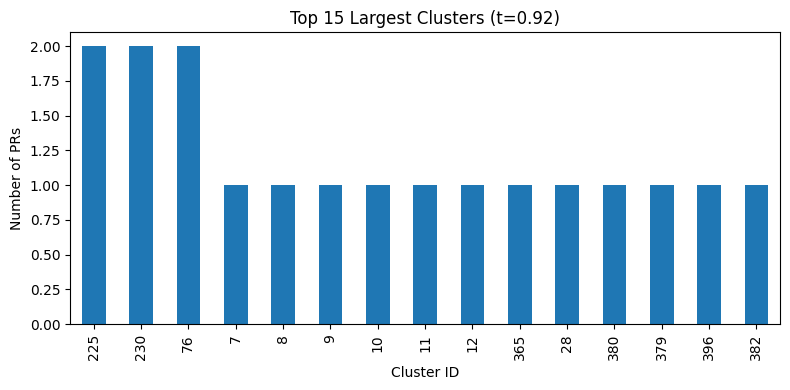

In [30]:
import matplotlib.pyplot as plt

top_n = 15
top_sizes = sizes.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(8, 4))
top_sizes.plot(kind='bar')
plt.title(f"Top {top_n} Largest Clusters (t=0.92)")
plt.xlabel("Cluster ID")
plt.ylabel("Number of PRs")
plt.tight_layout()
plt.show()


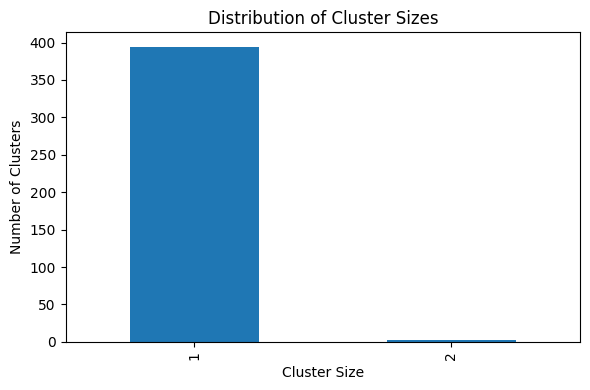

In [31]:
plt.figure(figsize=(6, 4))
sizes.value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Cluster Sizes")
plt.xlabel("Cluster Size")
plt.ylabel("Number of Clusters")
plt.tight_layout()
plt.show()


In [ ]:
# Block 31

print("Total clusters:", len(sizes))
print("Single-PR clusters:", (sizes==1).sum())
print("Multi-PR clusters:", (sizes>1).sum())
print("Largest cluster size:", sizes.max())


Total clusters: 14
Single-PR clusters: 0
Multi-PR clusters: 14
Largest cluster size: 374


XXXXXXXXXXXXXXXXXXXXXX  New addition to previous Code XXXXXXXXXXXXXXXXXXXXXX

Import DBSCAN

In [33]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

Load embeddings and index file

In [34]:
import numpy as np
import pandas as pd

emb = np.load("data/wesnoth_embeddings.npy")
df = pd.read_csv("data/wesnoth_index.csv")

print("Embeddings shape:", emb.shape)
print("Rows in CSV:", len(df))

Embeddings shape: (400, 384)
Rows in CSV: 400


In [35]:
dbscan = DBSCAN(
    eps=0.25,            # distance threshold (we will tune)
    min_samples=2,       # minimum points to form a cluster
    metric="cosine"
)

db_labels = dbscan.fit_predict(emb)

df["cluster_id_dbscan"] = db_labels
df.to_csv("artifacts/cluster_results_dbscan.csv", index=False)

print("DBSCAN done ✅")


DBSCAN done ✅


In [36]:
sizes = df.groupby("cluster_id_dbscan")["number"].count().sort_values(ascending=False)

print("Total clusters:", len(sizes))
print("Noise points (label = -1):", (df["cluster_id_dbscan"] == -1).sum())
print("Clusters with ≥2 PRs:", (sizes >= 2).sum())
print("Largest cluster size:", sizes.max())

sizes.head(10)

Total clusters: 14
Noise points (label = -1): 374
Clusters with ≥2 PRs: 14
Largest cluster size: 374


cluster_id_dbscan
-1    374
 0      2
 1      2
 2      2
 3      2
 4      2
 5      2
 6      2
 7      2
 8      2
Name: number, dtype: int64

Compare to Agglomerative

In [37]:
agg = pd.read_csv("artifacts/cluster_results_092.csv")

merged = df.merge(agg[["number","cluster_id"]], on="number", how="left")
merged.rename(columns={"cluster_id":"cluster_agg","cluster_id_dbscan":"cluster_db"}, inplace=True)

merged.to_csv("artifacts/cluster_compare.csv", index=False)
print("Comparison file saved ✅")

Comparison file saved ✅


In [38]:
merged = pd.read_csv("artifacts/cluster_compare.csv")
merged.head(10)
len(merged), merged.columns.tolist()
merged


,number,title,labels,url,cluster_db,cluster_agg
0,10651,Make help_manager a proper singleton,"UI,Editor,Help",https://github.com/wesnoth/wesnoth/pull/10651,-1,0
1,10644,Registry for Abilities,"Units,Schema",https://github.com/wesnoth/wesnoth/pull/10644,-1,1
2,10632,"Adjust L2/L3 Merfolk hp, damage, xp, and cost",Units,https://github.com/wesnoth/wesnoth/pull/10632,-1,2
3,10617,TSG: assorted tutorial improvements,"Graphics,Units,Achievements,Campaign TSG",https://github.com/wesnoth/wesnoth/pull/10617,0,3
4,10650,WoF changelog entries for 1.19.16,NaN,https://github.com/wesnoth/wesnoth/pull/10650,-1,4
...,...,...,...,...,...,...
395,9897,Only attempt to load .cfg scenarios in MP lobby,MP Lobby,https://github.com/wesnoth/wesnoth/pull/9897,-1,392
396,9955,lua api: expose male/female names for races,Lua API,https://github.com/wesnoth/wesnoth/pull/9955,-1,393
397,9953,"TDG: remove silent raven speed reduction, and ...",Campaign TDG,https://github.com/wesnoth/wesnoth/pull/9953,-1,394
398,9374,fixup #8766,Campaign DW,https://github.com/wesnoth/wesnoth/pull/9374,-1,395


Basic summaries

How many items in each cluster set. How much noise in DBSCAN.

In [39]:
# Agglomerative at 0.92
print("Agg clusters:", merged["cluster_agg"].nunique())
print(merged["cluster_agg"].value_counts().head(10))

# DBSCAN
print("\nDBSCAN clusters:", merged.loc[merged["cluster_db"]!=-1, "cluster_db"].nunique())
print("DBSCAN noise points:", (merged["cluster_db"]==-1).sum())
print(merged["cluster_db"].value_counts().head(10))


Agg clusters: 397
cluster_agg
76     2
225    2
230    2
5      1
6      1
7      1
8      1
9      1
10     1
11     1
Name: count, dtype: int64

DBSCAN clusters: 13
DBSCAN noise points: 374
cluster_db
-1    374
 0      2
 1      2
 2      2
 3      2
 4      2
 5      2
 6      2
 7      2
 8      2
Name: count, dtype: int64


Match DBSCAN clusters to nearest agglomerative clusters

For each DBSCAN cluster, find the majority agglomerative cluster inside it. This gives you a simple purity score.

In [40]:
import numpy as np

# ignore noise for purity
sub = merged[merged["cluster_db"] != -1].copy()

# majority match map: db_cluster -> agg_cluster
majority_map = (
    sub.groupby(["cluster_db","cluster_agg"])["number"]
       .count()
       .reset_index(name="count")
       .sort_values(["cluster_db","count"], ascending=[True, False])
       .groupby("cluster_db")
       .first()["cluster_agg"]
       .to_dict()
)

# purity per DBSCAN cluster
rows = []
for db_id, g in sub.groupby("cluster_db"):
    agg_target = majority_map.get(db_id)
    correct = (g["cluster_agg"] == agg_target).sum()
    purity = correct / len(g)
    rows.append({"cluster_db": db_id, "size": len(g), "mapped_agg": agg_target, "purity": purity})

purity_df = pd.DataFrame(rows).sort_values(["purity","size"], ascending=[False, False])
purity_df.head(20)


,cluster_db,size,mapped_agg,purity
1,1,2,76,1.0
6,6,2,225,1.0
7,7,2,230,1.0
0,0,2,3,0.5
2,2,2,87,0.5
3,3,2,101,0.5
4,4,2,177,0.5
5,5,2,195,0.5
8,8,2,234,0.5
9,9,2,286,0.5


Overall purity and coverage

In [41]:
overall_purity = (sub.apply(lambda r: majority_map.get(r["cluster_db"]) == r["cluster_agg"], axis=1).sum()) / len(sub)
coverage = len(sub) / len(merged)  # share of points that DBSCAN clustered, not noise
print(f"Overall purity on clustered points: {overall_purity:.3f}")
print(f"Coverage (not noise): {coverage:.3f}")


Overall purity on clustered points: 0.615
Coverage (not noise): 0.065


Optional agreement metrics

Adjusted Rand Index treats clusters as labels. Drop the noise to compute it.

In [42]:
from sklearn.metrics import adjusted_rand_score

mask = merged["cluster_db"] != -1
if mask.sum() > 0:
    ari = adjusted_rand_score(merged.loc[mask,"cluster_agg"], merged.loc[mask,"cluster_db"])
    print("Adjusted Rand Index on non noise:", ari)
else:
    print("All points are noise under DBSCAN. Adjust eps or min_samples.")


Adjusted Rand Index on non noise: 0.36548223350253806


C:\Users\kaosa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


Top example clusters to inspect

Pick a few of the largest DBSCAN clusters and list their titles and links. This helps you judge quality by eye.

In [43]:
# largest DBSCAN clusters
largest_db = merged[merged["cluster_db"]!=-1]["cluster_db"].value_counts().head(5).index.tolist()
largest_db


[0, 1, 2, 3, 4]

In [44]:
# join back to titles and urls to browse
idx = pd.read_csv("data/wesnoth_index.csv")  # has number, title, url
for cid in largest_db:
    print(f"\nDBSCAN cluster {cid}")
    nums = merged.loc[merged["cluster_db"]==cid, "number"].tolist()
    view = idx[idx["number"].isin(nums)][["number","title","url"]]
    display(view.head(10))



DBSCAN cluster 0


,number,title,url
3,10617,TSG: assorted tutorial improvements,https://github.com/wesnoth/wesnoth/pull/10617
203,9811,TSG: some S01/S02 tweaks,https://github.com/wesnoth/wesnoth/pull/9811



DBSCAN cluster 1


,number,title,url
76,10545,MP: Fix lag during AI turns on 5P The Wilderlands,https://github.com/wesnoth/wesnoth/pull/10545
77,10482,MP: Fix lag during AI turns on 5P The Wilderlands,https://github.com/wesnoth/wesnoth/pull/10482



DBSCAN cluster 2


,number,title,url
88,10495,AToTB S4 Map: Aesthetic Revision,https://github.com/wesnoth/wesnoth/pull/10495
378,9947,AToTB S3 Map: Aesthetic Revision,https://github.com/wesnoth/wesnoth/pull/9947



DBSCAN cluster 3


,number,title,url
102,10474,[1.18] Make the Load Game dialog see other-ver...,https://github.com/wesnoth/wesnoth/pull/10474
103,10475,Make the Load Game dialog for 1.19 and 1.20 se...,https://github.com/wesnoth/wesnoth/pull/10475



DBSCAN cluster 4


,number,title,url
178,10355,Backport 1.18: Change Japanese font to Noto Sa...,https://github.com/wesnoth/wesnoth/pull/10355
183,10353,Fonts: Change Japanese font to Noto Sans JP (#...,https://github.com/wesnoth/wesnoth/pull/10353


Quick DBSCAN tuning sweep

Try a few eps values to see noise rate and cluster count. Keep it small and fast.

In [45]:
import numpy as np
from sklearn.cluster import DBSCAN

emb = np.load("data/wesnoth_embeddings.npy")

def try_dbscan(eps_list=(0.20,0.22,0.24,0.26,0.28), min_samples=2):
    out = []
    for eps in eps_list:
        labels = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine").fit_predict(emb)
        n_noise = (labels==-1).sum()
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        out.append({"eps": eps, "clusters": n_clusters, "noise": n_noise})
    return pd.DataFrame(out)

try_dbscan()


,eps,clusters,noise
0,0.20,8,384
1,0.22,10,380
2,0.24,12,376
3,0.26,13,374
4,0.28,16,367


If you want, save that table.

In [46]:
sweep = try_dbscan()
sweep.to_csv("artifacts/dbscan_sweep.csv", index=False)
sweep


,eps,clusters,noise
0,0.20,8,384
1,0.22,10,380
2,0.24,12,376
3,0.26,13,374
4,0.28,16,367


In the following, we will do these:

1) PCA 2-D scatter plot of embeddings

2) Color points by cluster ID (Agglomerative & DBSCAN separately)

3) Highlight noise points for DBSCAN (label = –1)  

Step-1: Import plotting tools

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


Step-2: PCA transform to 2D

In [48]:
# Load agglomerative cluster results
df = pd.read_csv("artifacts/cluster_results_092.csv")

# Load DBSCAN results and append DBSCAN labels
db_df = pd.read_csv("artifacts/cluster_results_dbscan.csv")

# Merge both (ensures we have cluster_id & cluster_id_dbscan)
df = df.merge(db_df[["number","cluster_id_dbscan"]], on="number", how="left")

print(df.columns)

Index(['number', 'title', 'labels', 'url', 'cluster_id', 'cluster_id_dbscan'], dtype='object')


In [49]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb)

df["pca_x"] = emb_2d[:,0]
df["pca_y"] = emb_2d[:,1]


Step-3: Visualize Agglomerative Clusters

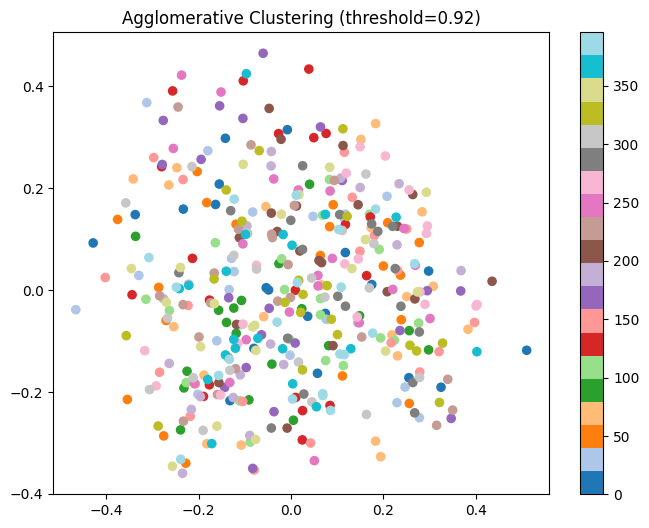

In [50]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df["pca_x"], df["pca_y"], c=df["cluster_id"], cmap="tab20", s=35)
plt.title("Agglomerative Clustering (threshold=0.92)")
plt.colorbar(scatter)
plt.show()


Step-4: Visualize DBSCAN

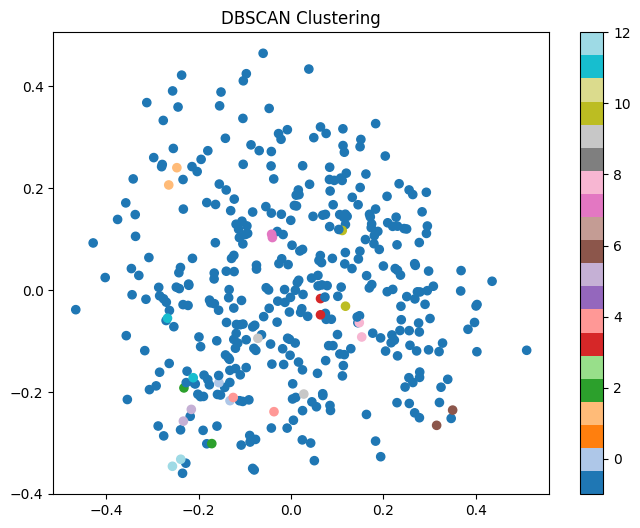

In [51]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df["pca_x"], df["pca_y"], 
    c=df["cluster_id_dbscan"], 
    cmap="tab20", 
    s=35
)
plt.title("DBSCAN Clustering")
plt.colorbar(scatter)
plt.show()


Optional: Highlight noise in DBSCAN

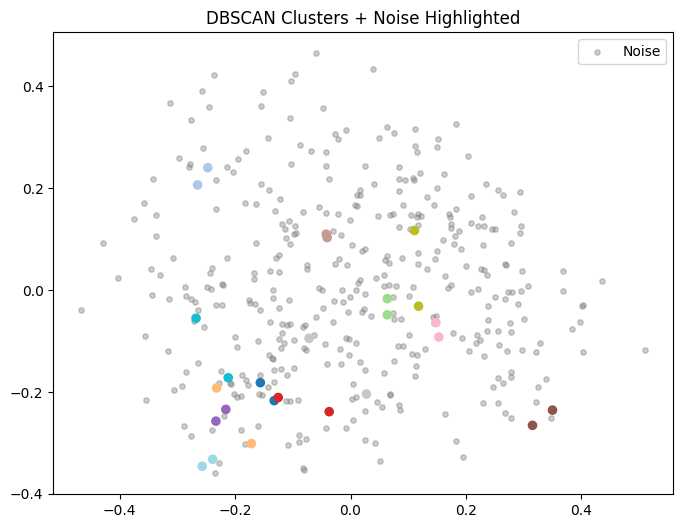

In [52]:
plt.figure(figsize=(8,6))

noise_mask = df["cluster_id_dbscan"] == -1
cluster_mask = ~noise_mask

plt.scatter(df.loc[noise_mask,"pca_x"], df.loc[noise_mask,"pca_y"], 
            color="gray", s=15, alpha=0.4, label="Noise")

plt.scatter(df.loc[cluster_mask,"pca_x"], df.loc[cluster_mask,"pca_y"], 
            c=df.loc[cluster_mask,"cluster_id_dbscan"], cmap="tab20", s=35)

plt.legend()
plt.title("DBSCAN Clusters + Noise Highlighted")
plt.show()
